# Laboratorio 2 - Complejidad y búsqueda de hiperparámetros

**Curso:** ISIS2611  
**Nombres:**
- Angel Felipe Restrepo Castillo - 201914073
- Laura Valentina Jimenez Tovar -201924116


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import validation_curve

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    OneHotEncoder,
    FunctionTransformer,
    PolynomialFeatures
)

from sklearn.impute import SimpleImputer

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso
)

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

from sklearn.utils import resample

In [5]:
datos_meteorologicos = pd.read_csv('./data/Datos Lab 1.csv')
datos_test = pd.read_csv('./data/Datos Test Lab 1.csv')
data = datos_meteorologicos.copy()
data_test = datos_test.copy()
print("Datos de entrenamiento:", data.shape)
print("Datos de test:", data_test.shape)

Datos de entrenamiento: (2576, 27)
Datos de test: (364, 26)


In [15]:
data.dtypes

fecha                 object
presion_media        float64
presion_min          float64
presion_max          float64
presion_desv         float64
humedad_media        float64
humedad_min          float64
humedad_max          float64
humedad_desv         float64
viento_media         float64
viento_min           float64
viento_max           float64
viento_desv          float64
rafaga_media         float64
rafaga_min           float64
rafaga_max           float64
rafaga_desv          float64
viento_norte         float64
viento_este          float64
direccion_viento     float64
registros_del_dia    float64
anio                 float64
dia_del_anio         float64
estacion_anio         object
mes                   object
sector_viento         object
temp_max_manana      float64
dtype: object

In [16]:
porcentaje_nulos = (
    data.isnull().sum() / data.shape[0] * 100
).sort_values(ascending=False)

porcentaje_nulos

temp_max_manana      3.687888
viento_min           3.532609
estacion_anio        3.416149
mes                  3.416149
anio                 3.338509
humedad_max          3.338509
viento_media         3.338509
viento_max           3.144410
humedad_min          3.105590
viento_norte         3.105590
presion_desv         3.105590
rafaga_desv          3.066770
direccion_viento     3.066770
rafaga_media         3.027950
registros_del_dia    2.989130
presion_media        2.911491
presion_min          2.872671
humedad_media        2.872671
rafaga_max           2.833851
rafaga_min           2.795031
viento_desv          2.795031
fecha                2.795031
sector_viento        2.756211
dia_del_anio         2.639752
presion_max          2.484472
viento_este          2.484472
humedad_desv         2.368012
dtype: float64

In [17]:
duplicados = data.duplicated().sum()

print(f"Número de registros duplicados: {duplicados}")

Número de registros duplicados: 4


In [19]:
#Variable objetivo
target = "temp_max_manana"

# Separamos los predictores de la variable objetivo
X = data.drop(columns=[target])
y = data[target]

X_test = data_test.copy()

print("X:", X.shape)
print("y:", y.shape)
print("X_test:", X_test.shape)

X: (2576, 26)
y: (2576,)
X_test: (364, 26)


In [20]:
# Eliminar duplicados del conjunto de datos
data = data.drop_duplicates()

print(f"Registros después de eliminar duplicados: {data.shape[0]}")

Registros después de eliminar duplicados: 2572


In [21]:
data_entrenamiento = data[data[target].notna()].copy()

# Separamos predictores y variable objetivo
X = data_entrenamiento.drop(columns=[target])
y = data_entrenamiento[target]

print("X:", X.shape)
print("y:", y.shape)

X: (2477, 26)
y: (2477,)


In [22]:
numeric_features = [
    "presion_media",
    "presion_min",
    "presion_max",
    "presion_desv",
    "humedad_media",
    "humedad_min",
    "humedad_max",
    "humedad_desv",
    "viento_media",
    "viento_min",
    "viento_max",
    "viento_desv",
    "rafaga_media",
    "rafaga_min",
    "rafaga_max",
    "rafaga_desv",
    "viento_norte",
    "viento_este",
    "direccion_viento",
    "registros_del_dia",
    "anio",
    "dia_del_anio"
]

In [23]:
categorical_features = [
    "estacion_anio",
    "mes",
    "sector_viento"
]

## 1. Construcción de un modelo de regresión polinomial

Transformador para variables numéricas

In [26]:
# Pipeline para las variables numéricas
numeric_transformer = Pipeline(
    steps=[
        # Los valores faltantes se reemplazan por la mediana
        ("imputer", SimpleImputer(strategy="median")),

        # Estandarizamos las variables antes de generar
        # las características polinomiales
        ("scaler", StandardScaler()),

        # Generar términos polinomiales.
        # El grado es  hiperparámetro
        # para poder buscarlo posteriormente con GridSearchCV
        ("polynomial", PolynomialFeatures(
            degree=2,
            include_bias=False
        ))
    ]
)

Transformador para variables categóricas

In [28]:
# Pipeline para las variables categóricas
categorical_transformer = Pipeline(
    steps=[
        # Reemplazar los valores faltantes por
        # la categoría que aparece con mayor frecuencia
        ("imputer", SimpleImputer(strategy="most_frequent")),

        # Convertir las categorías a variables numéricas
        # mediante One-Hot Encoding
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

Unir ambos transformadores

In [30]:
# Combinar el procesamiento de las variables
# numéricas y categóricas
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ],

    # Las columnas que no estén en estas listas
    # serán descartadas.
    # En particular, aquí queda fuera "fecha".
    remainder="drop"
)

Crear el Pipeline completo

In [31]:
# Construir el pipeline completo del modelo polinomial
pipeline_polinomial = Pipeline(
    steps=[
        # Primero se realiza todo el preprocesamiento
        ("preprocesamiento", preprocessor),

        # Después se entrena una regresión lineal
        # sobre las características polinomiales
        ("modelo", LinearRegression())
    ]
)

In [32]:
# Transofrmar los datos para observar cuántas
# características se generan después del preprocesamiento
X_transformado = preprocessor.fit_transform(X)

print("Características originales:", X.shape[1])
print("Características después del preprocesamiento:", X_transformado.shape[1])

Características originales: 26
Características después del preprocesamiento: 397


GridSearchCV

In [33]:
# Se definen los grados del polinomio que serán evaluados
param_grid = {
    "preprocesamiento__num__polynomial__degree": [1, 2, 3]
}

In [34]:
# Se configura la búsqueda de hiperparámetros utilizando validación cruzada
grid_search = GridSearchCV(
    estimator=pipeline_polinomial,
    param_grid=param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    return_train_score=True
)

In [35]:
# Se entrenan y comparan los modelos correspondientes a cada grado
grid_search.fit(X, y)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocesamiento',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler()),
                                                                                         ('polynomial',
                                                                                          PolynomialFeatures(include_bias=False))]),
                                                                         ['presion_media',
                                                                          'presion_min',
                                                                          'presion_max',
                                                                          'presion_desv',
                                                                          'humedad_media',
                                                                          'humedad_min',
                                                                          'humedad_max...
                                                                          'anio',
                                                                          'dia_del_anio']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['estacion_anio',
                                                                          'mes',
                                                                          'sector_viento'])])),
                                       ('modelo', LinearRegression())]),
             param_grid={'preprocesamiento__num__polynomial__degree': [1, 2,
                                                                       3]},
             return_train_score=True, scoring='neg_root_mean_squared_error')

Obtener el mejor grado

In [36]:
# Se obtiene el mejor grado encontrado por GridSearchCV
mejor_grado = grid_search.best_params_[
    "preprocesamiento__num__polynomial__degree"
]

# Se obtiene el mejor RMSE promedio de validación cruzada
mejor_rmse = -grid_search.best_score_

print(f"Mejor grado: {mejor_grado}")
print(f"Mejor RMSE de validación cruzada: {mejor_rmse:.4f}")

Mejor grado: 1
Mejor RMSE de validación cruzada: 24.9768


Ver el desempeño de cada grado

In [37]:
# Se extraen los resultados obtenidos durante la búsqueda
resultados_grid = pd.DataFrame(grid_search.cv_results_)

# Se seleccionan las columnas relevantes para comparar los grados
resultados_grados = resultados_grid[
    [
        "param_preprocesamiento__num__polynomial__degree",
        "mean_train_score",
        "std_train_score",
        "mean_test_score",
        "std_test_score"
    ]
].copy()

# Se convierten los valores negativos de RMSE a RMSE positivo
resultados_grados["RMSE_train"] = (
    -resultados_grados["mean_train_score"]
)

resultados_grados["RMSE_validacion"] = (
    -resultados_grados["mean_test_score"]
)

# Se conserva la desviación estándar de la validación cruzada
resultados_grados["Std_RMSE_validacion"] = (
    resultados_grados["std_test_score"]
)

# Se organiza la tabla por grado
resultados_grados = resultados_grados.sort_values(
    "param_preprocesamiento__num__polynomial__degree"
)

resultados_grados[
    [
        "param_preprocesamiento__num__polynomial__degree",
        "RMSE_train",
        "RMSE_validacion",
        "Std_RMSE_validacion"
    ]
]

,param_preprocesamiento__num__polynomial__degree,RMSE_train,RMSE_validacion,Std_RMSE_validacion
0,1,6.403814,2.497682e+01,3.579051e+01
1,2,4.348890,2.152045e+09,2.611771e+09
2,3,0.009959,6.160016e+09,1.231805e+10


Al aumentar la complejidad, el modelo logra ajustarse cada vez mejor a los datos de entrenamiento, pero pierde capacidad de generalización

## 2. Generación de curvas de validación. 


Curva de validación

In [38]:
# Se definen los grados del polinomio que serán evaluados
grados = np.array([1, 2, 3])

# Se calculan los errores de entrenamiento y validación
# mediante validación cruzada para cada grado
train_scores, validation_scores = validation_curve(
    pipeline_polinomial,
    X,
    y,
    param_name="preprocesamiento__num__polynomial__degree",
    param_range=grados,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

In [39]:
# Se convierte el RMSE negativo utilizado por scikit-learn
# a valores positivos para facilitar su interpretación
rmse_train = -train_scores
rmse_validacion = -validation_scores

# Se calcula el promedio del RMSE para cada grado
rmse_train_promedio = rmse_train.mean(axis=1)
rmse_validacion_promedio = rmse_validacion.mean(axis=1)

# Se calcula la desviación estándar del RMSE de validación
# para representar la variabilidad entre los folds
rmse_validacion_std = rmse_validacion.std(axis=1)

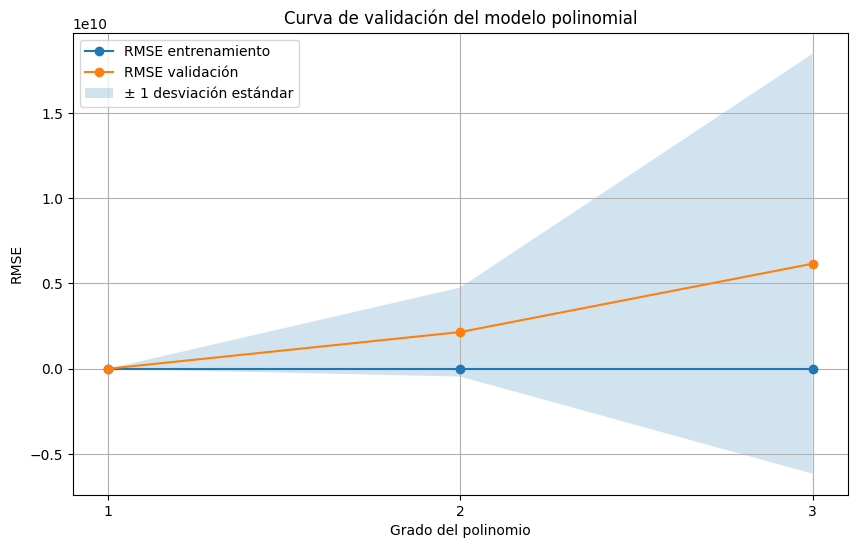

In [40]:
# Se crea la figura para visualizar las curvas de validación
plt.figure(figsize=(10, 6))

# Se grafica el error promedio de entrenamiento
plt.plot(
    grados,
    rmse_train_promedio,
    marker="o",
    label="RMSE entrenamiento"
)

# Se grafica el error promedio de validación
plt.plot(
    grados,
    rmse_validacion_promedio,
    marker="o",
    label="RMSE validación"
)

# Se representa la variabilidad de la validación
# mediante una banda de una desviación estándar
plt.fill_between(
    grados,
    rmse_validacion_promedio - rmse_validacion_std,
    rmse_validacion_promedio + rmse_validacion_std,
    alpha=0.2,
    label="± 1 desviación estándar"
)

plt.xlabel("Grado del polinomio")
plt.ylabel("RMSE")
plt.title("Curva de validación del modelo polinomial")
plt.xticks(grados)
plt.legend()
plt.grid(True)
plt.show()

Al aumentar el grado del polinomio, disminuye el sesgo porque el modelo adquiere mayor capacidad para representar los datos. Sin embargo, a partir del grado 2 la varianza aumenta considerablemente, lo que provoca una pérdida de generalización. El grado 3 presenta el caso más extremo: el error de entrenamiento es prácticamente cero, mientras que el error de validación es muy elevado y altamente variable.

## 3. Construcción de modelos de regresión lineal regularizados.

Crear los transformadores

In [42]:
# Se construye el pipeline para las variables numéricas
numeric_transformer_regularizado = Pipeline(
    steps=[
        # Se reemplazan los valores faltantes por la mediana
        ("imputer", SimpleImputer(strategy="median")),

        # Se estandarizan las variables numéricas
        ("scaler", StandardScaler())
    ]
)

In [43]:
# Se construye el pipeline para las variables categóricas
categorical_transformer_regularizado = Pipeline(
    steps=[
        # Se reemplazan los valores faltantes por la categoría
        # más frecuente
        ("imputer", SimpleImputer(strategy="most_frequent")),

        # Se convierten las categorías en variables binarias
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

Crear el ColumnTransformer

In [44]:
# Se combinan los transformadores numéricos y categóricos
preprocessor_regularizado = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer_regularizado,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer_regularizado,
            categorical_features
        )
    ],

    # Se descartan las columnas que no están incluidas
    # en las listas anteriores, como "fecha"
    remainder="drop"
)

Crear el modelo Ridge

In [45]:
# Se construye el pipeline para el modelo Ridge
pipeline_ridge = Pipeline(
    steps=[
        # Se realiza el preprocesamiento de los datos
        ("preprocesamiento", preprocessor_regularizado),

        # Se utiliza regresión Ridge
        ("modelo", Ridge())
    ]
)

Definir los valores de alpha

In [50]:
# Se definen diferentes niveles de regularización
param_grid_ridge = {
    "modelo__alpha": [
        0.001,
        0.01,
        0.1,
        1,
        10,
        100,
        1000,
        10000
    ]
}

In [51]:
# Se configura la búsqueda del mejor valor de alpha
# mediante validación cruzada
grid_ridge = GridSearchCV(
    estimator=pipeline_ridge,
    param_grid=param_grid_ridge,
    cv=5,
    scoring="neg_root_mean_squared_error",
    return_train_score=True
)

In [52]:
# Se entrenan los modelos Ridge para todos los valores de alpha
grid_ridge.fit(X, y)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocesamiento',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['presion_media',
                                                                          'presion_min',
                                                                          'presion_max',
                                                                          'presion_desv',
                                                                          'humedad_media',
                                                                          'humedad_min',
                                                                          'humedad_max',
                                                                          'humedad_desv',
                                                                          'viento_media',
                                                                          'viento_min',
                                                                          'viento_m...
                                                                          'registros_del_dia',
                                                                          'anio',
                                                                          'dia_del_anio']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['estacion_anio',
                                                                          'mes',
                                                                          'sector_viento'])])),
                                       ('modelo', Ridge())]),
             param_grid={'modelo__alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000,
                                           10000]},
             return_train_score=True, scoring='neg_root_mean_squared_error')

In [53]:
# Se obtiene el mejor valor de alpha encontrado
mejor_alpha_ridge = grid_ridge.best_params_["modelo__alpha"]

# Se obtiene el RMSE promedio de validación
mejor_rmse_ridge = -grid_ridge.best_score_

print(f"Mejor alpha Ridge: {mejor_alpha_ridge}")
print(f"Mejor RMSE Ridge: {mejor_rmse_ridge:.4f}")

Mejor alpha Ridge: 10000
Mejor RMSE Ridge: 12.8973


Resultados de Ridge

In [54]:
# Se extraen los resultados obtenidos durante la búsqueda
resultados_ridge = pd.DataFrame(grid_ridge.cv_results_)

# Se seleccionan las columnas necesarias para analizar
# el efecto del parámetro de regularización
resultados_ridge = resultados_ridge[
    [
        "param_modelo__alpha",
        "mean_train_score",
        "std_train_score",
        "mean_test_score",
        "std_test_score"
    ]
].copy()

# Se convierten los valores negativos de RMSE
# a valores positivos
resultados_ridge["RMSE_train"] = (
    -resultados_ridge["mean_train_score"]
)

resultados_ridge["RMSE_validacion"] = (
    -resultados_ridge["mean_test_score"]
)

# Se conserva la desviación estándar de validación
resultados_ridge["Std_RMSE_validacion"] = (
    resultados_ridge["std_test_score"]
)

resultados_ridge[
    [
        "param_modelo__alpha",
        "RMSE_train",
        "RMSE_validacion",
        "Std_RMSE_validacion"
    ]
]

,param_modelo__alpha,RMSE_train,RMSE_validacion,Std_RMSE_validacion
0,0.001,6.403817,24.985059,35.805975
1,0.010,6.403833,24.979556,35.798155
2,0.100,6.404740,24.952472,35.768110
3,1.000,6.415351,24.785819,35.553438
4,10.000,6.471112,22.955687,32.140047
5,100.000,6.710580,16.180216,18.517253
6,1000.000,7.222291,15.966390,17.105901
7,10000.000,8.519020,12.897284,8.249696


El modelo polinomial aumentaba su complejidad y rápidamente empeoraba en validación, mientras que Ridge consigue mejorar la generalización mediante la regularización.

Pipeline Lasso

In [55]:
# Se construye el pipeline para el modelo Lasso
pipeline_lasso = Pipeline(
    steps=[
        # Se realiza el preprocesamiento de los datos
        ("preprocesamiento", preprocessor_regularizado),

        # Se utiliza regresión Lasso
        ("modelo", Lasso(max_iter=10000))
    ]
)

Definir los valores de alpha

In [56]:
# Se definen diferentes niveles de regularización para Lasso
param_grid_lasso = {
    "modelo__alpha": [
        0.001,
        0.01,
        0.1,
        1,
        10,
        100
    ]
}

In [57]:
# Se configura la búsqueda del mejor alpha mediante
# validación cruzada
grid_lasso = GridSearchCV(
    estimator=pipeline_lasso,
    param_grid=param_grid_lasso,
    cv=5,
    scoring="neg_root_mean_squared_error",
    return_train_score=True
)

In [58]:
# Se entrenan los modelos Lasso para los diferentes valores de alpha
grid_lasso.fit(X, y)

C:\Users\laura\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_coordinate_descent.py:658: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 2199.6109857639676, tolerance: 16.725152484944605
  model = cd_fast.sparse_enet_coordinate_descent(
C:\Users\laura\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_coordinate_descent.py:658: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 1929.399557157296, tolerance: 16.67567646173176
  model = cd_fast.sparse_enet_coordinate_descent(
C:\Users\laura\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_coordinate_descent.py:658: Convergenc

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocesamiento',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['presion_media',
                                                                          'presion_min',
                                                                          'presion_max',
                                                                          'presion_desv',
                                                                          'humedad_media',
                                                                          'humedad_min',
                                                                          'humedad_max',
                                                                          'humedad_desv',
                                                                          'viento_media',
                                                                          'viento_min',
                                                                          'viento_m...
                                                                          'registros_del_dia',
                                                                          'anio',
                                                                          'dia_del_anio']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['estacion_anio',
                                                                          'mes',
                                                                          'sector_viento'])])),
                                       ('modelo', Lasso(max_iter=10000))]),
             param_grid={'modelo__alpha': [0.001, 0.01, 0.1, 1, 10, 100]},
             return_train_score=True, scoring='neg_root_mean_squared_error')

Resultado de Lasso

In [59]:
# Se obtiene el mejor valor de alpha encontrado para Lasso
mejor_alpha_lasso = grid_lasso.best_params_["modelo__alpha"]

# Se obtiene el mejor RMSE promedio de validación
mejor_rmse_lasso = -grid_lasso.best_score_

print(f"Mejor alpha Lasso: {mejor_alpha_lasso}")
print(f"Mejor RMSE Lasso: {mejor_rmse_lasso:.4f}")

Mejor alpha Lasso: 1
Mejor RMSE Lasso: 7.6004


In [60]:
# Se extraen los resultados obtenidos durante la búsqueda de Lasso
resultados_lasso = pd.DataFrame(grid_lasso.cv_results_)

# Se seleccionan las columnas necesarias para analizar
# el efecto del parámetro de regularización
resultados_lasso = resultados_lasso[
    [
        "param_modelo__alpha",
        "mean_train_score",
        "std_train_score",
        "mean_test_score",
        "std_test_score"
    ]
].copy()

# Se convierten los valores negativos de RMSE
# a valores positivos
resultados_lasso["RMSE_train"] = (
    -resultados_lasso["mean_train_score"]
)

resultados_lasso["RMSE_validacion"] = (
    -resultados_lasso["mean_test_score"]
)

# Se conserva la desviación estándar del RMSE
# obtenido durante la validación cruzada
resultados_lasso["Std_RMSE_validacion"] = (
    resultados_lasso["std_test_score"]
)

resultados_lasso[
    [
        "param_modelo__alpha",
        "RMSE_train",
        "RMSE_validacion",
        "Std_RMSE_validacion"
    ]
]

,param_modelo__alpha,RMSE_train,RMSE_validacion,Std_RMSE_validacion
0,0.001,6.407120,24.624778,35.170251
1,0.010,6.501895,22.813276,31.864733
2,0.100,6.823375,10.105154,6.282590
3,1.000,7.440384,7.600435,0.380664
4,10.000,9.210555,9.328381,0.612749
5,100.000,9.210555,9.328381,0.612749


Comparación de los tres modelos

In [61]:
# Se obtiene el RMSE y la desviación estándar del mejor
# modelo polinomial encontrado
rmse_lineal = -grid_search.best_score_

resultados_lineal = pd.DataFrame(
    grid_search.cv_results_
)

fila_lineal = resultados_lineal[
    resultados_lineal[
        "param_preprocesamiento__num__polynomial__degree"
    ] == 1
].iloc[0]

std_lineal = fila_lineal["std_test_score"]

# Se construye una tabla comparativa de los modelos
comparacion_modelos = pd.DataFrame({
    "Modelo": [
        "Regresión lineal",
        "Ridge",
        "Lasso"
    ],
    "Mejor hiperparámetro": [
        "degree = 1",
        f"alpha = {mejor_alpha_ridge}",
        f"alpha = {mejor_alpha_lasso}"
    ],
    "RMSE validación": [
        rmse_lineal,
        mejor_rmse_ridge,
        mejor_rmse_lasso
    ],
    "Std. RMSE validación": [
        std_lineal,
        resultados_ridge.loc[
            resultados_ridge["RMSE_validacion"].idxmin(),
            "Std_RMSE_validacion"
        ],
        resultados_lasso.loc[
            resultados_lasso["RMSE_validacion"].idxmin(),
            "Std_RMSE_validacion"
        ]
    ]
})

comparacion_modelos

,Modelo,Mejor hiperparámetro,RMSE validación,Std. RMSE validación
0,Regresión lineal,degree = 1,24.976818,35.790509
1,Ridge,alpha = 10000,12.897284,8.249696
2,Lasso,alpha = 1,7.600435,0.380664


In [62]:
# Se obtiene el mejor pipeline encontrado para Lasso
mejor_lasso = grid_lasso.best_estimator_

# Se extraen los coeficientes del modelo Lasso
coeficientes_lasso = mejor_lasso.named_steps[
    "modelo"
].coef_

print(f"Número de coeficientes: {len(coeficientes_lasso)}")

Número de coeficientes: 144


In [63]:
# Se obtiene el transformador de variables numéricas y categóricas
preprocesador_lasso = mejor_lasso.named_steps[
    "preprocesamiento"
]

# Se obtienen los nombres de las características generadas
nombres_caracteristicas = preprocesador_lasso.get_feature_names_out()

# Se construye una tabla con cada característica y su coeficiente
coeficientes_lasso_df = pd.DataFrame({
    "Variable": nombres_caracteristicas,
    "Coeficiente": coeficientes_lasso
})

coeficientes_lasso_df

,Variable,Coeficiente
0,num__presion_media,-0.000000
1,num__presion_min,0.000000
2,num__presion_max,0.000000
3,num__presion_desv,-0.486873
4,num__humedad_media,-0.000000
...,...,...
139,cat__sector_viento_ne,0.000000
140,cat__sector_viento_no,-0.000000
141,cat__sector_viento_o,-0.000000
142,cat__sector_viento_s,-0.000000


En la comparación de los modelos lineales, Lasso presentó el mejor desempeño, con un RMSE promedio de validación de 7.6004 y una desviación estándar de 0.3806, superando tanto a la regresión lineal (RMSE = 24.9768) como a Ridge (RMSE = 12.8973). Además, Lasso mostró una variabilidad mucho menor entre los folds de validación, lo que indica un comportamiento más estable y una mejor capacidad de generalización. Por su parte, Ridge también mejoró considerablemente respecto a la regresión lineal, aunque con un desempeño inferior al de Lasso. Estos resultados sugieren que la regularización permite controlar la complejidad del modelo y mejorar su desempeño fuera de los datos de entrenamiento, siendo Lasso con α = 1 el modelo más favorable entre los evaluados hasta este punto.

## 4. Construcción de un modelo de regresión polinomial regularizado.

Crear el transformador numérico

In [64]:
# Se construye el pipeline para las variables numéricas
# del modelo polinomial regularizado
numeric_transformer_poly_ridge = Pipeline(
    steps=[
        # Se reemplazan los valores faltantes por la mediana
        ("imputer", SimpleImputer(strategy="median")),

        # Se estandarizan las variables antes de generar
        # las características polinomiales
        ("scaler", StandardScaler()),

        # Se generan características polinomiales.
        # El grado se definirá posteriormente mediante GridSearchCV
        ("polynomial", PolynomialFeatures(
            degree=2,
            include_bias=False
        ))
    ]
)

Transformador categórico

In [67]:
# Se construye el pipeline para las variables categóricas
categorical_transformer_poly_ridge = Pipeline(
    steps=[
        # Se reemplazan los valores faltantes por
        # la categoría más frecuente
        ("imputer", SimpleImputer(strategy="most_frequent")),

        # Se convierten las categorías en variables binarias
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

Crear el ColumnTransformer

In [70]:
# Se combinan los transformadores numéricos y categóricos
preprocessor_poly_ridge = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer_poly_ridge,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer_poly_ridge,
            categorical_features
        )
    ],
    # Se descartan las variables que no forman parte
    # de las características seleccionadas
    remainder="drop"
)

Crear el pipeline Ridge polinomial

In [71]:
# Se construye el pipeline completo para Ridge polinomial
pipeline_poly_ridge = Pipeline(
    steps=[
        # Se realiza el preprocesamiento y la generación
        # de características polinomiales
        ("preprocesamiento", preprocessor_poly_ridge),

        # Se aplica regularización Ridge
        ("modelo", Ridge())
    ]
)

Definir los hiperparámetros

In [72]:
# Se definen los valores de los hiperparámetros
# que serán evaluados mediante GridSearchCV
param_grid_poly_ridge = {
    "preprocesamiento__num__polynomial__degree": [1, 2, 3],

    "preprocesamiento__num__scaler": [
        StandardScaler(),
        MinMaxScaler()
    ],

    "modelo__alpha": [
        0.1,
        1,
        10,
        100,
        1000,
        10000
    ]
}

Configurar GridSearchCV

In [73]:
# Se configura la búsqueda sistemática de grado,
# escalamiento y nivel de regularización
grid_poly_ridge = GridSearchCV(
    estimator=pipeline_poly_ridge,
    param_grid=param_grid_poly_ridge,
    cv=5,
    scoring="neg_root_mean_squared_error",
    return_train_score=True,
    n_jobs=-1
)

In [74]:
# Se entrenan todas las combinaciones de hiperparámetros
grid_poly_ridge.fit(X, y)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocesamiento',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler()),
                                                                                         ('polynomial',
                                                                                          PolynomialFeatures(include_bias=False))]),
                                                                         ['presion_media',
                                                                          'presion_min',
                                                                          'presion_max',
                                                                          'presion_desv',
                                                                          'humedad_media',
                                                                          'humedad_min',
                                                                          'humedad_max...
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['estacion_anio',
                                                                          'mes',
                                                                          'sector_viento'])])),
                                       ('modelo', Ridge())]),
             n_jobs=-1,
             param_grid={'modelo__alpha': [0.1, 1, 10, 100, 1000, 10000],
                         'preprocesamiento__num__polynomial__degree': [1, 2, 3],
                         'preprocesamiento__num__scaler': [StandardScaler(),
                                                           MinMaxScaler()]},
             return_train_score=True, scoring='neg_root_mean_squared_error')

Mejor combinación de hiperparámetros

In [75]:
# Se obtienen los mejores hiperparámetros encontrados
mejores_parametros_poly_ridge = grid_poly_ridge.best_params_

# Se obtiene el mejor RMSE promedio de validación
mejor_rmse_poly_ridge = -grid_poly_ridge.best_score_

print("Mejores hiperparámetros:")
print(mejores_parametros_poly_ridge)

print(f"\nMejor RMSE de validación: {mejor_rmse_poly_ridge:.4f}")

Mejores hiperparámetros:
{'modelo__alpha': 1000, 'preprocesamiento__num__polynomial__degree': 1, 'preprocesamiento__num__scaler': MinMaxScaler()}

Mejor RMSE de validación: 9.1363


Extraer los resultados de todas las combinaciones

In [76]:
# Se extraen los resultados obtenidos durante GridSearchCV
resultados_poly_ridge = pd.DataFrame(
    grid_poly_ridge.cv_results_
)

# Se seleccionan las columnas necesarias para analizar
# los hiperparámetros y el desempeño
resultados_poly_ridge = resultados_poly_ridge[
    [
        "param_modelo__alpha",
        "param_preprocesamiento__num__polynomial__degree",
        "param_preprocesamiento__num__scaler",
        "mean_train_score",
        "mean_test_score",
        "std_test_score"
    ]
].copy()

# Se convierten los valores negativos de RMSE
# a valores positivos
resultados_poly_ridge["RMSE_train"] = (
    -resultados_poly_ridge["mean_train_score"]
)

resultados_poly_ridge["RMSE_validacion"] = (
    -resultados_poly_ridge["mean_test_score"]
)

# Se conserva la desviación estándar de la validación
resultados_poly_ridge["Std_RMSE_validacion"] = (
    resultados_poly_ridge["std_test_score"]
)

# Se ordenan los resultados desde el menor RMSE
resultados_poly_ridge = resultados_poly_ridge.sort_values(
    "RMSE_validacion"
)

resultados_poly_ridge[
    [
        "param_modelo__alpha",
        "param_preprocesamiento__num__polynomial__degree",
        "param_preprocesamiento__num__scaler",
        "RMSE_train",
        "RMSE_validacion",
        "Std_RMSE_validacion"
    ]
].head(10)

,param_modelo__alpha,param_preprocesamiento__num__polynomial__degree,param_preprocesamiento__num__scaler,RMSE_train,RMSE_validacion,Std_RMSE_validacion
25,1000.0,1,MinMaxScaler(),8.670331,9.136258,0.615946
31,10000.0,1,MinMaxScaler(),9.141179,9.265579,0.610198
19,100.0,1,MinMaxScaler(),7.269342,12.199100,9.229553
30,10000.0,1,StandardScaler(),8.519020,12.897284,8.249696
24,1000.0,1,StandardScaler(),7.222291,15.966390,17.105901
18,100.0,1,StandardScaler(),6.710580,16.180216,18.517253
13,10.0,1,MinMaxScaler(),6.536637,19.287803,24.704892
12,10.0,1,StandardScaler(),6.471112,22.955687,32.140047
7,1.0,1,MinMaxScaler(),6.450529,23.768446,33.542024
6,1.0,1,StandardScaler(),6.415351,24.785819,35.553438


Mejor resultado de cada grado

In [77]:
# Se agrupan los resultados según el grado del polinomio
# y se identifica la mejor combinación de cada grado
mejores_por_grado = (
    resultados_poly_ridge
    .sort_values("RMSE_validacion")
    .groupby(
        "param_preprocesamiento__num__polynomial__degree",
        as_index=False
    )
    .first()
)

# Se seleccionan las columnas relevantes para la comparación
mejores_por_grado[
    [
        "param_preprocesamiento__num__polynomial__degree",
        "param_modelo__alpha",
        "param_preprocesamiento__num__scaler",
        "RMSE_train",
        "RMSE_validacion",
        "Std_RMSE_validacion"
    ]
]

,param_preprocesamiento__num__polynomial__degree,param_modelo__alpha,param_preprocesamiento__num__scaler,RMSE_train,RMSE_validacion,Std_RMSE_validacion
0,1,1000.0,MinMaxScaler(),8.670331,9.136258,0.615946
1,2,10000.0,MinMaxScaler(),8.912971,27.260160,36.170368
2,3,10000.0,MinMaxScaler(),8.380419,1945.485654,3873.750906


Los resultados muestran que Ridge controla parcialmente el sobreajuste observado en la regresión polinomial sin regularización, pero aumentar el grado del polinomio sigue perjudicando la generalización. El mejor modelo corresponde al grado 1, alpha = 1000 y MinMaxScaler, con un RMSE de validación de 9.1363 y una desviación estándar de 0.6160. Al aumentar a grado 2, el RMSE de validación aumenta a 27.2602 y la variabilidad alcanza 36.1704, mientras que en grado 3 el error aumenta drásticamente hasta 1945.4855. Por tanto, para estos datos, aumentar la complejidad polinomial no genera mejoras en la predicción; por el contrario, incluso con regularización, los grados superiores presentan problemas de generalización. Esto respalda la selección de un modelo de baja complejidad y fuertemente regularizado.

## Actividad 5: comparación y selección del mejor modelo

In [78]:
# Se construye una tabla con el desempeño de los modelos evaluados
comparacion_final = pd.DataFrame({
    "Modelo": [
        "Regresión lineal",
        "Ridge",
        "Lasso",
        "Ridge polinomial"
    ],
    "Configuración": [
        "degree = 1",
        f"alpha = {mejor_alpha_ridge}",
        f"alpha = {mejor_alpha_lasso}",
        "degree = 1, alpha = 1000, MinMaxScaler"
    ],
    "RMSE_CV": [
        rmse_lineal,
        mejor_rmse_ridge,
        mejor_rmse_lasso,
        mejor_rmse_poly_ridge
    ],
    "Std_RMSE_CV": [
        std_lineal,
        resultados_ridge.loc[
            resultados_ridge["RMSE_validacion"].idxmin(),
            "Std_RMSE_validacion"
        ],
        resultados_lasso.loc[
            resultados_lasso["RMSE_validacion"].idxmin(),
            "Std_RMSE_validacion"
        ],
        grid_poly_ridge.cv_results_["std_test_score"][
            grid_poly_ridge.best_index_
        ]
    ]
})

# Se ordenan los modelos desde el menor RMSE
comparacion_final = comparacion_final.sort_values(
    "RMSE_CV"
).reset_index(drop=True)

comparacion_final

,Modelo,Configuración,RMSE_CV,Std_RMSE_CV
0,Lasso,alpha = 1,7.600435,0.380664
1,Ridge polinomial,"degree = 1, alpha = 1000, MinMaxScaler",9.136258,0.615946
2,Ridge,alpha = 10000,12.897284,8.249696
3,Regresión lineal,degree = 1,24.976818,35.790509


Identificar el modelo seleccionado

In [79]:
# Se identifica el modelo con menor RMSE promedio de validación
mejor_modelo = comparacion_final.iloc[0]

print("Modelo seleccionado:")
print(mejor_modelo["Modelo"])

print(f"\nConfiguración: {mejor_modelo['Configuración']}")
print(f"RMSE CV: {mejor_modelo['RMSE_CV']:.4f}")
print(f"Std. RMSE CV: {mejor_modelo['Std_RMSE_CV']:.4f}")

Modelo seleccionado:
Lasso

Configuración: alpha = 1
RMSE CV: 7.6004
Std. RMSE CV: 0.3807


Comparar visualmente los modelos

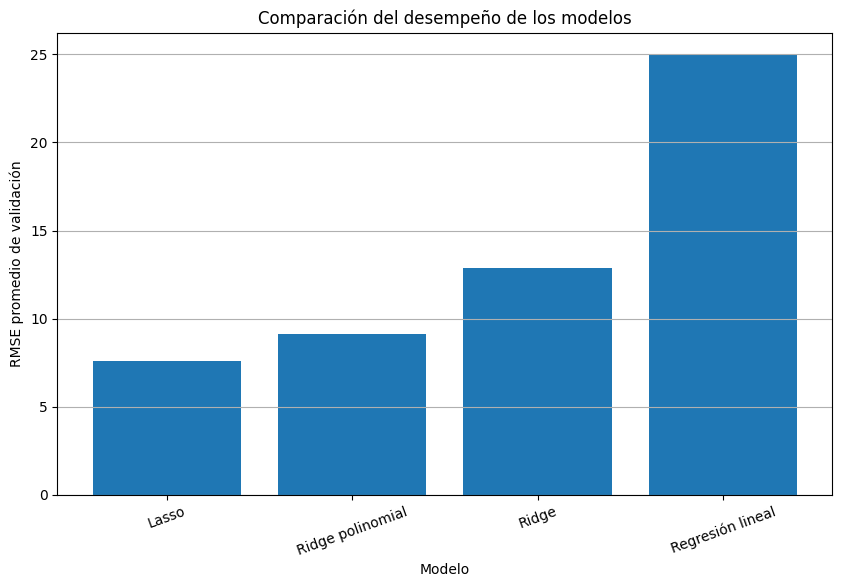

In [80]:
# Se crea una gráfica para comparar el RMSE promedio
# de validación de los modelos
plt.figure(figsize=(10, 6))

plt.bar(
    comparacion_final["Modelo"],
    comparacion_final["RMSE_CV"]
)

plt.xlabel("Modelo")
plt.ylabel("RMSE promedio de validación")
plt.title("Comparación del desempeño de los modelos")
plt.xticks(rotation=20)
plt.grid(axis="y")

plt.show()

Analizar la estabilidad

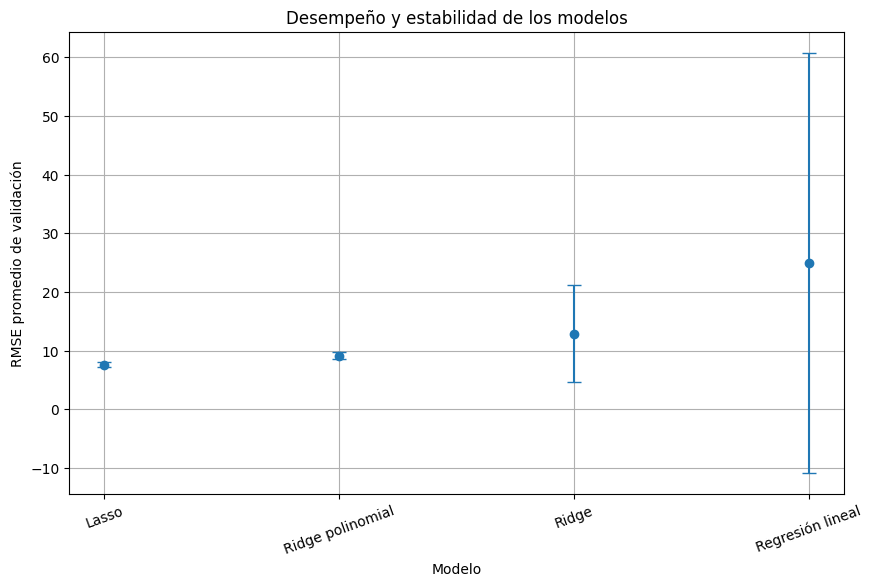

In [81]:
# Se crea una gráfica del RMSE promedio con su variabilidad
plt.figure(figsize=(10, 6))

plt.errorbar(
    comparacion_final["Modelo"],
    comparacion_final["RMSE_CV"],
    yerr=comparacion_final["Std_RMSE_CV"],
    fmt="o",
    capsize=5
)

plt.xlabel("Modelo")
plt.ylabel("RMSE promedio de validación")
plt.title("Desempeño y estabilidad de los modelos")
plt.xticks(rotation=20)
plt.grid(True)

plt.show()

A partir de la comparación realizada mediante validación cruzada, Lasso con α = 1 fue seleccionado como el mejor modelo, al obtener el menor RMSE promedio (7.6004) y una desviación estándar muy baja (0.3807), lo que indica un desempeño preciso y estable entre los diferentes folds. Ridge y Ridge polinomial también mejoraron respecto a la regresión lineal, pero presentaron errores superiores de 12.8973 y 9.1363, respectivamente. Además, la regresión lineal mostró una variabilidad considerablemente mayor, con una desviación estándar de 35.7905. En conjunto, los resultados sugieren que la regularización L1 de Lasso permite controlar adecuadamente la complejidad del modelo y mejorar su capacidad de generalización, ofreciendo hasta este punto el mejor equilibrio entre precisión y estabilidad.

## 6. Construcción de intervalos de confianza.

Crear el conjunto de entrenamiento y prueba

In [82]:
# Se divide el conjunto con variable objetivo conocida
# en entrenamiento y prueba
X_train_bootstrap, X_test_bootstrap, y_train_bootstrap, y_test_bootstrap = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

print("X_train:", X_train_bootstrap.shape)
print("X_test:", X_test_bootstrap.shape)
print("y_train:", y_train_bootstrap.shape)
print("y_test:", y_test_bootstrap.shape)

X_train: (1857, 26)
X_test: (620, 26)
y_train: (1857,)
y_test: (620,)


Obtener el mejor modelo Lasso

In [83]:
# Se obtiene el mejor pipeline Lasso encontrado anteriormente
modelo_final = grid_lasso.best_estimator_

print(modelo_final)

Pipeline(steps=[('preprocesamiento',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['presion_media',
                                                   'presion_min', 'presion_max',
                                                   'presion_desv',
                                                   'humedad_media',
                                                   'humedad_min', 'humedad_max',
                                                   'humedad_desv',
                                                   'viento_media', 'viento_min',
                                                

In [84]:
# Se entrena el modelo seleccionado utilizando
# únicamente el conjunto de entrenamiento
modelo_final.fit(
    X_train_bootstrap,
    y_train_bootstrap
)

Pipeline(steps=[('preprocesamiento',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['presion_media',
                                                   'presion_min', 'presion_max',
                                                   'presion_desv',
                                                   'humedad_media',
                                                   'humedad_min', 'humedad_max',
                                                   'humedad_desv',
                                                   'viento_media', 'viento_min',
                                                   'viento_max', 'viento_desv',
                                                   'rafaga_media', 'rafaga_min',
                                                   'rafaga_max', 'rafaga_desv',
                                                   'viento_norte',
                                                   'viento_este',
                                                   'direccion_viento',
                                                   'registros_del_dia', 'anio',
                                                   'dia_del_anio']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['estacion_anio', 'mes',
                                                   'sector_viento'])])),
                ('modelo', Lasso(alpha=1, max_iter=10000))])

Obtener las predicciones

In [85]:
# Se generan las predicciones sobre el conjunto de prueba
y_test_pred = modelo_final.predict(X_test_bootstrap)

# Se muestran algunas predicciones para comprobar el resultado
y_test_pred[:10]

array([13.01907729, 20.00049148, 11.05040114, 13.85618892, 18.13997277,
        9.37542489, 11.34004794, 19.05298769, 16.46525746, 12.09549568])

Calcular las métricas originales

In [86]:
# Se calcula el RMSE sobre el conjunto de prueba
rmse_test = np.sqrt(
    mean_squared_error(
        y_test_bootstrap,
        y_test_pred
    )
)

# Se calcula el MAE sobre el conjunto de prueba
mae_test = mean_absolute_error(
    y_test_bootstrap,
    y_test_pred
)

# Se calcula R² sobre el conjunto de prueba
r2_test = r2_score(
    y_test_bootstrap,
    y_test_pred
)

print("=== MÉTRICAS SOBRE EL CONJUNTO DE PRUEBA ===")
print(f"RMSE: {rmse_test:.4f}")
print(f"MAE:  {mae_test:.4f}")
print(f"R²:   {r2_test:.4f}")

=== MÉTRICAS SOBRE EL CONJUNTO DE PRUEBA ===
RMSE: 7.4913
MAE:  5.9504
R²:   0.3447


Bootstrap

Se mantiene fijo el modelo Lasso ya entrenado y se remuestrean las observaciones del conjunto de prueba para estudiar cuánto pueden variar las métricas si se tuviera una muestra diferente de datos.

In [87]:
# Se establece el número de remuestreos
n_bootstrap = 1000

# Se crean listas para almacenar las métricas
rmse_bootstrap = []
mae_bootstrap = []
r2_bootstrap = []

# Se realizan los remuestreos
for i in range(n_bootstrap):

    # Se generan índices aleatorios con reemplazo
    indices = resample(
        np.arange(len(y_test_bootstrap)),
        replace=True,
        random_state=i
    )

    # Se seleccionan los valores reales y predichos
    # correspondientes a los índices seleccionados
    y_real_muestra = y_test_bootstrap.iloc[indices]
    y_pred_muestra = y_test_pred[indices]

    # Se calcula RMSE para la muestra
    rmse_muestra = np.sqrt(
        mean_squared_error(
            y_real_muestra,
            y_pred_muestra
        )
    )

    # Se calcula MAE para la muestra
    mae_muestra = mean_absolute_error(
        y_real_muestra,
        y_pred_muestra
    )

    # Se calcula R² para la muestra
    r2_muestra = r2_score(
        y_real_muestra,
        y_pred_muestra
    )

    # Se almacenan los resultados
    rmse_bootstrap.append(rmse_muestra)
    mae_bootstrap.append(mae_muestra)
    r2_bootstrap.append(r2_muestra)

Intervalos de confianza del 95 %

In [88]:
# Se calculan los intervalos de confianza del 95%
# utilizando los percentiles de las distribuciones Bootstrap
ic_rmse = np.percentile(
    rmse_bootstrap,
    [2.5, 97.5]
)

ic_mae = np.percentile(
    mae_bootstrap,
    [2.5, 97.5]
)

ic_r2 = np.percentile(
    r2_bootstrap,
    [2.5, 97.5]
)

print("Intervalos de confianza del 95%")
print(f"RMSE: [{ic_rmse[0]:.4f}, {ic_rmse[1]:.4f}]")
print(f"MAE:  [{ic_mae[0]:.4f}, {ic_mae[1]:.4f}]")
print(f"R²:   [{ic_r2[0]:.4f}, {ic_r2[1]:.4f}]")

Intervalos de confianza del 95%
RMSE: [7.0306, 8.0060]
MAE:  [5.5955, 6.2998]
R²:   [0.2865, 0.3956]


Distribuciones Bootstrap

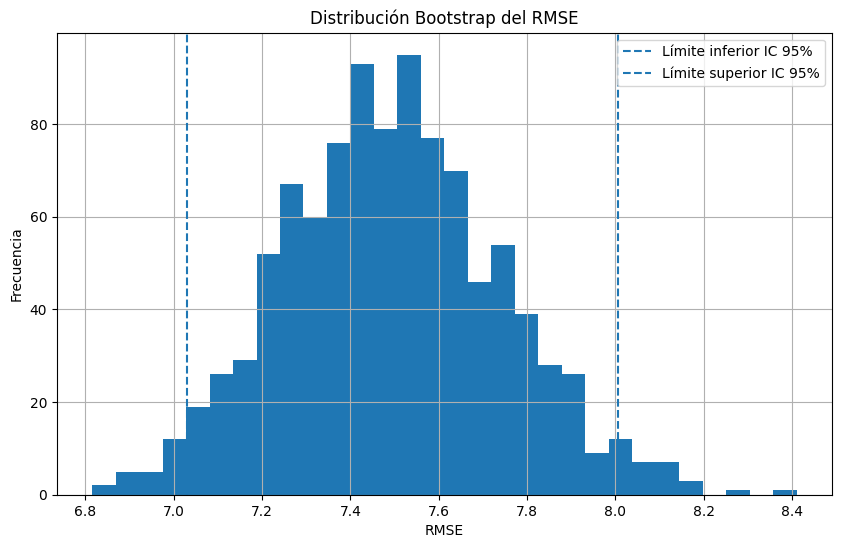

In [89]:
# Se visualiza la distribución Bootstrap del RMSE
plt.figure(figsize=(10, 6))

plt.hist(
    rmse_bootstrap,
    bins=30
)

# Se muestran los límites del intervalo de confianza
plt.axvline(
    ic_rmse[0],
    linestyle="--",
    label="Límite inferior IC 95%"
)

plt.axvline(
    ic_rmse[1],
    linestyle="--",
    label="Límite superior IC 95%"
)

plt.xlabel("RMSE")
plt.ylabel("Frecuencia")
plt.title("Distribución Bootstrap del RMSE")
plt.legend()
plt.grid(True)

plt.show()

MAE

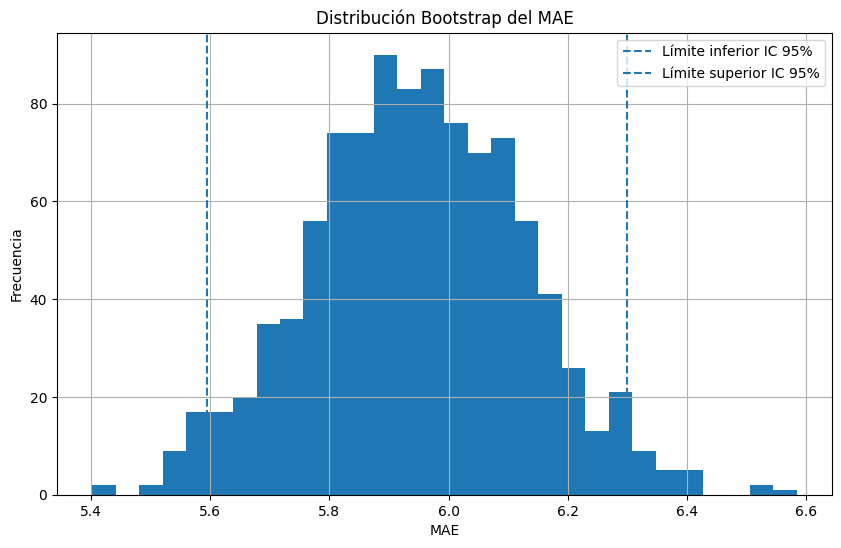

In [90]:
# Se visualiza la distribución Bootstrap del MAE
plt.figure(figsize=(10, 6))

plt.hist(
    mae_bootstrap,
    bins=30
)

# Se muestran los límites del intervalo de confianza
plt.axvline(
    ic_mae[0],
    linestyle="--",
    label="Límite inferior IC 95%"
)

plt.axvline(
    ic_mae[1],
    linestyle="--",
    label="Límite superior IC 95%"
)

plt.xlabel("MAE")
plt.ylabel("Frecuencia")
plt.title("Distribución Bootstrap del MAE")
plt.legend()
plt.grid(True)

plt.show()

R²

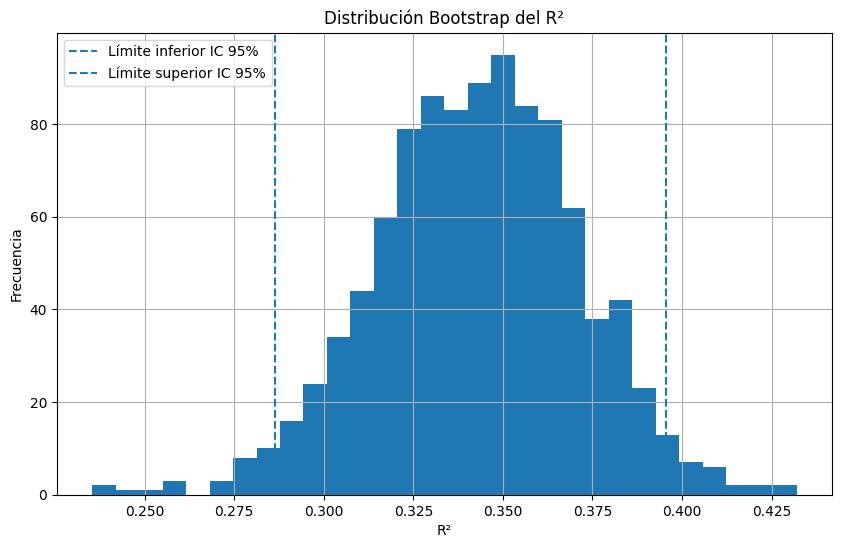

In [91]:
# Se visualiza la distribución Bootstrap del R²
plt.figure(figsize=(10, 6))

plt.hist(
    r2_bootstrap,
    bins=30
)

# Se muestran los límites del intervalo de confianza
plt.axvline(
    ic_r2[0],
    linestyle="--",
    label="Límite inferior IC 95%"
)

plt.axvline(
    ic_r2[1],
    linestyle="--",
    label="Límite superior IC 95%"
)

plt.xlabel("R²")
plt.ylabel("Frecuencia")
plt.title("Distribución Bootstrap del R²")
plt.legend()
plt.grid(True)

plt.show()

Resumen de los intervalos

In [92]:
# Se construye una tabla resumen con los intervalos de confianza
resultados_bootstrap = pd.DataFrame({
    "Métrica": [
        "RMSE",
        "MAE",
        "R²"
    ],
    "Límite inferior 95%": [
        ic_rmse[0],
        ic_mae[0],
        ic_r2[0]
    ],
    "Límite superior 95%": [
        ic_rmse[1],
        ic_mae[1],
        ic_r2[1]
    ]
})

resultados_bootstrap

,Métrica,Límite inferior 95%,Límite superior 95%
0,RMSE,7.030553,8.006015
1,MAE,5.595465,6.299751
2,R²,0.286523,0.395636


El análisis Bootstrap realizado mediante 1000 remuestreos permitió cuantificar la incertidumbre asociada al desempeño del modelo Lasso. Con un nivel de confianza del 95 %, el RMSE se encuentra entre 7.0306 y 8.0060, mientras que el MAE se encuentra entre 5.5955 y 6.2998, lo que evidencia una variabilidad relativamente baja en los errores de predicción. Por otro lado, el R² presenta un intervalo entre 0.2865 y 0.3956, indicando una capacidad explicativa moderada y cierta variabilidad en función de la muestra evaluada. En conjunto, los resultados respaldan la estabilidad del desempeño predictivo del modelo Lasso, aunque también muestran que existe espacio para mejorar su capacidad de explicar la variabilidad de la temperatura máxima.

# Análisis de resultados

### Análisis cuantitatvo.

1. ¿Cuál modelo obtuvo el mejor desempeño?
Lasso (α = 1) obtuvo el mejor desempeño, con RMSE promedio de 7.6004 (± 0.3807), superando a Ridge polinomial (9.1363), Ridge (12.8973) y regresión lineal (24.9768).

2. ¿Coincide el mejor desempeño con el mejor promedio en validación cruzada?
Sí, coincide: Lasso (α = 1) fue también el mejor en validación cruzada (RMSE 7.6004), con una desviación estándar baja (0.3807) que confirma la consistencia del resultado.

3. ¿El modelo con mejor métrica promedio es necesariamente el más adecuado?
No necesariamente; también debe evaluarse la estabilidad. Lasso destaca en ambos criterios: menor RMSE (7.6004) y menor desviación estándar (0.3807), frente a Ridge (12.8973 ± 8.2497) y regresión lineal (24.9768 ± 35.7905).

4. ¿Cómo cambia el error con la complejidad? ¿Dónde se evidencia sobreajuste?
Al aumentar el grado del polinomio, el error de entrenamiento baja mientras el de validación se dispara: grado 1 (6.40 / 24.98), grado 2 (4.35 / 2152.04), grado 3 (0.0096 / ~6.16 millones). El sobreajuste aparece desde el grado 2 y se vuelve extremo en el grado 3, ilustrando el trade-off sesgo-varianza.

5. ¿Cómo afecta la regularización la magnitud y estabilidad de los coeficientes?
Ridge (L2) reduce los coeficientes sin llevarlos a cero; Lasso (L1) puede anularlos, haciendo selección de variables. Con 144 características, Lasso logró un desempeño estable (RMSE 7.6004 ± 0.3807), simplificando el modelo.

6. ¿Los intervalos de confianza (bootstrapping) sugieren estabilidad o variabilidad?
Los intervalos (1000 remuestreos) muestran baja variabilidad en RMSE [7.0306, 8.0060] y MAE [5.5955, 6.2998]. El R² [0.2865, 0.3956] es más amplio, indicando que el modelo es estable en su error pero explica solo una parte moderada de la variabilidad de la temperatura.

## Análisis cualitativo.

1. ¿Qué variables fueron seleccionadas como más relevantes por Lasso?
De las 144 características generadas (numéricas + One-Hot Encoding), Lasso destacó humedad_desv (coef. ≈ 4.216) y presion_desv (coef. ≈ −0.487) como las de mayor magnitud, mientras otras se acercaron a cero. La relevancia completa se determina ordenando los coeficientes por valor absoluto.

2. ¿Qué interpretación práctica tienen los coeficientes en la estimación de temp_max?
Al estar las variables estandarizadas, cada coeficiente refleja el cambio esperado en temp_max_manana por un aumento de una desviación estándar en esa variable (positivo = relación directa, negativo = inversa). Por ejemplo, humedad_desv (≈4.216) indica que su aumento eleva la temperatura predicha. En categóricas, los coeficientes reflejan diferencias frente a la categoría de referencia.

3. ¿Hay diferencias entre el modelo más preciso y el más interpretable?
Sí. Lasso fue el más preciso (RMSE 7.6004 ± 0.3807), pero la regresión lineal es conceptualmente más simple de interpretar. Aun así, Lasso reduce su complejidad efectiva al anular coeficientes, logrando un buen equilibrio entre precisión e interpretabilidad.

4. ¿Qué decisiones estratégicas podría tomar AlpesPlanck?
Usar el modelo para anticipar temperaturas y planificar actividades sensibles al clima, enfocar el monitoreo en las variables más influyentes, y preferir modelos como Lasso (preciso y estable) sobre alternativas polinomiales que generalizan mal. Antes de implementarlo, validar con nuevos datos y definir métricas de seguimiento.

5. ¿Mayor precisión implica mayor valor para la organización?
No necesariamente. El valor depende de si las mejoras en predicción se traducen en mejores decisiones o menores costos. Lasso es atractivo no solo por su bajo RMSE (7.6004) sino por su estabilidad (desviación 0.3807), por lo que la elección debe ponderar precisión, estabilidad, interpretabilidad y costo.

6. ¿Un modelo más complejo genera mayor valor empresarial?
No. Mayor complejidad (PolynomialFeatures) redujo el error de entrenamiento pero disparó el de validación (grado 2: 2152.04; grado 3: ~6.16 millones), mostrando sobreajuste; incluso con Ridge, el grado 2 empeoró (27.2602 vs. 9.1363 en grado 1). Lasso, más simple y regularizado, logró mejor equilibrio (RMSE 7.6004 ± 0.3807). Para AlpesPlanck, conviene priorizar precisión suficiente junto con estabilidad, interpretabilidad y sostenibilidad.

## Reflexión conceptual

1. ¿Qué relación hay entre complejidad, generalización y estabilidad?
Mayor complejidad no garantiza mejor generalización: en la regresión polinomial, el error de validación pasó de 24.98 (grado 1) a 2152.04 (grado 2) y ~6.16 millones (grado 3), con mayor variabilidad entre folds, evidenciando sobreajuste. En contraste, Lasso controló la complejidad y logró error bajo y estable (RMSE 7.6004, std 0.3807). Existe entonces un equilibrio: modelos muy simples tienden al sesgo, y muy complejos, a la varianza y menor generalización.

2. ¿Qué fuentes de sesgo podrían existir en los datos o el modelado?
Pueden originarse en la representatividad de los datos (condiciones meteorológicas no cubiertas), valores faltantes o errores de medición, y en decisiones del modelado (selección de variables, transformaciones inadecuadas). Además, los modelos lineales asumen relaciones que podrían no capturar todos los patrones, y el caso polinomial muestra que aumentar la complejidad tampoco corrige esto, sino que generó sobreajuste.

3. ¿Un mayor tamaño de muestra cambiaría la estabilidad de los modelos?
Sí, probablemente la mejoraría, al permitir estimaciones más robustas y particiones de validación más representativas, reduciendo la variabilidad entre folds y favoreciendo la generalización de modelos complejos. No obstante, más datos no soluciona el problema si estos contienen sesgos o baja calidad. Lasso ya muestra buena estabilidad (std RMSE = 0.3807), pero una muestra mayor permitiría confirmar con más confianza si este comportamiento se mantiene.

## Uso IA

Declaración del uso
Se utilizó ChatGPT como apoyo en la elaboración del laboratorio, principalmente para explicar conceptos de regresión polinomial y regularizada, construir y depurar código, interpretar resultados y redactar conclusiones. Se usó como herramienta de apoyo, no como sustituto del razonamiento: el código fue revisado, ejecutado y ajustado según los datos y requerimientos del laboratorio.

Prompts principales utilizados

"Dame parte por parte del código para la construcción de un modelo de regresión polinomial y haz los comentarios necesarios."
"¿Cómo cambia el error a medida que aumenta la complejidad? ¿En qué punto se evidencia sobreajuste?"
"¿Cómo afecta la regularización la magnitud y estabilidad de los coeficientes?"
"Ajusta estas respuestas sobre los valores calculados."

Análisis crítico del resultado
La IA ayudó a estructurar el laboratorio y explicar conceptos como validación cruzada, sobreajuste, trade-off sesgo-varianza, regularización y Bootstrap, y a valorar la desviación estándar además del RMSE. Se detectaron ajustes necesarios frente a los datos reales: por ejemplo, se comprobó que Datos Test Lab 1.csv no contenía temp_max_manana, por lo que las métricas se calcularon con los datos etiquetados y validación cruzada. Los resultados del código se verificaron directamente en lugar de asumir las sugerencias de la IA como correctas; la selección de Lasso se basó en los valores experimentales (RMSE = 7.6004, desviación estándar = 0.3807).

Aportes propios del estudiante
El estudiante ejecutó el código, revisó resultados, tomó las decisiones sobre los modelos y validó las interpretaciones. Adaptó el código a los datos de AlpesPlanck (identificación de variables numéricas/categóricas, exclusión de fecha, selección de hiperparámetros con GridSearchCV). Las conclusiones finales se basaron en los conceptos del curso y en los resultados obtenidos experimentalmente, usando la IA solo como apoyo conceptual y de redacción.